# Array verification — new `SceneRenderer` pipeline

Interactive playground for sanity-checking the ULA forward model used by
the new data-generation pipeline (`reconunet.data.scene_renderer`).

**What this notebook shows**

1. Array geometry and nominal vs. perturbed element positions.
2. Steering-vector magnitude and phase across **all** angles, per element.
3. 2-D beam pattern (angle-vs-angle response) and 1-D vertical cuts with
   3 dB widths.
4. How the `mild` / `harsh` imperfection presets deform the response.

**Conventions used here (important — different from the legacy `ArrayModel`!)**

* Angle basis: **broadside-0°** (array axis along x, broadside along y).
* Steering: `a_m(θ) = exp(−j · 2π · m · (d/λ) · sin(θ))`.  (−j sign!)
* Angle range: `[−90°, +90°]`.

The legacy `signalgen.array_processing.ArrayModel` uses the *opposite* j-sign
and an endfire-0° basis.  That difference is why classical MUSIC in the
legacy harness needs the conversion `θ_broadside = ψ_classic − 90°`.


## 0. Imports and parameters

In [1]:
import sys, os
# Add src/ to path so the in-tree reconunet package imports cleanly.
_SRC = os.path.abspath(os.path.join(os.getcwd(), "..", "..", "src"))
if _SRC not in sys.path:
    sys.path.insert(0, _SRC)

import numpy as np
import matplotlib.pyplot as plt
from reconunet.data.scene_renderer import _steering_vector
from reconunet.data.scene_manifest import ManifestMeta

# ---------------------------------------------------------------------------
# Parameters — edit these and re-run the notebook
# ---------------------------------------------------------------------------
M                     = 8        # elements
ELEMENT_SPACING_LAMBDA = 0.5     # d / λ
PRESET                = "mild"   # "none" | "mild" | "harsh"
SEED                  = 0        # per-array imperfection draw

PRESETS = {
    "none":  dict(gain_err_dB=0.0, phase_err_deg=0.0, mutual_coupling=0.0, position_err_pct=0.0),
    "mild":  dict(gain_err_dB=0.1, phase_err_deg=1.0, mutual_coupling=0.02, position_err_pct=1.0),
    "harsh": dict(gain_err_dB=0.5, phase_err_deg=5.0, mutual_coupling=0.10, position_err_pct=5.0),
}
cfg = PRESETS[PRESET]
print(f"M={M}, d/λ={ELEMENT_SPACING_LAMBDA}, preset={PRESET}, seed={SEED}")
print(cfg)


M=8, d/λ=0.5, preset=mild, seed=0
{'gain_err_dB': 0.1, 'phase_err_deg': 1.0, 'mutual_coupling': 0.02, 'position_err_pct': 1.0}


## 1. Array geometry

Show the nominal ULA element positions and, for reference, what they
look like under the selected `position_err_pct`.


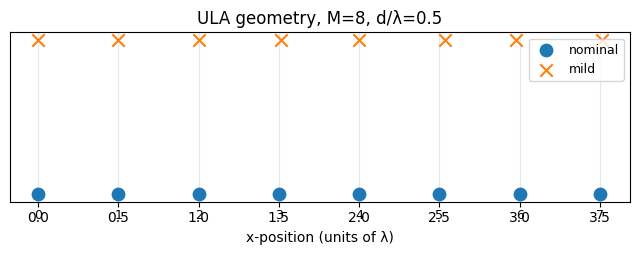

per-element gain (dB) : [ 0.01256377 -0.01322037  0.06380652  0.01048355 -0.05373211  0.03608399
  0.12942922  0.0941943 ]
per-element phase (°) : [-0.70373524 -1.26542147 -0.62327446  0.04132598 -2.32503077 -0.21879166
 -1.24591095 -0.73226735]
per-element dx / d (%): [-0.54425898 -0.31630016  0.41163054  1.04251337 -0.12853466  1.36646347
 -0.66519467  0.35151007]


In [2]:
rng = np.random.default_rng(SEED)

# Reproduce the error draws from SceneRenderer.render() so what we plot
# matches what the renderer actually uses for a scene with this preset.
gain_err      = 1.0 + (cfg["gain_err_dB"] / 8.686) * rng.standard_normal(M)
phase_err_rad = np.deg2rad(cfg["phase_err_deg"]) * rng.standard_normal(M)
pos_err_pct   = (cfg["position_err_pct"] / 100.0) * rng.standard_normal(M)

# Nominal + perturbed x-positions (in units of d)
m_idx = np.arange(M, dtype=np.float64)
x_nom  = m_idx * ELEMENT_SPACING_LAMBDA
x_pert = m_idx * ELEMENT_SPACING_LAMBDA * (1.0 + pos_err_pct)

fig, ax = plt.subplots(1, 1, figsize=(8, 2.2))
ax.scatter(x_nom,  np.zeros(M), s=80, marker="o", label="nominal", zorder=3)
ax.scatter(x_pert, 0.1 * np.ones(M), s=80, marker="x", label=f"{PRESET}", zorder=3)
for i in range(M):
    ax.annotate(f"{i}", (x_nom[i], 0), xytext=(0, -18), textcoords="offset points",
                ha="center", fontsize=9)
ax.set_yticks([])
ax.set_xlabel("x-position (units of λ)")
ax.set_title(f"ULA geometry, M={M}, d/λ={ELEMENT_SPACING_LAMBDA}")
ax.legend(loc="upper right", fontsize=9); ax.grid(alpha=0.3)
plt.show()

print(f"per-element gain (dB) : {20*np.log10(np.abs(gain_err))}")
print(f"per-element phase (°) : {np.rad2deg(phase_err_rad)}")
print(f"per-element dx / d (%): {100 * pos_err_pct}")


## 2. Steering vector magnitude and phase, per element, across angles

`a_m(θ)` is a complex number per antenna element and per angle.  Two
standard diagnostics:

* **Magnitude** — flat across angle for a calibrated array.  Ripple means
  per-element gain error and/or mutual-coupling is biting.
* **Phase** — a straight line versus `sin(θ)` (slope = `−2π·m·(d/λ)`).
  Deviations from a straight line expose phase-error and position-jitter.

The block below builds the `[M, G]` steering matrix `A(θ)` over a dense
grid and plots it two ways (all-element overlay + per-element lines).


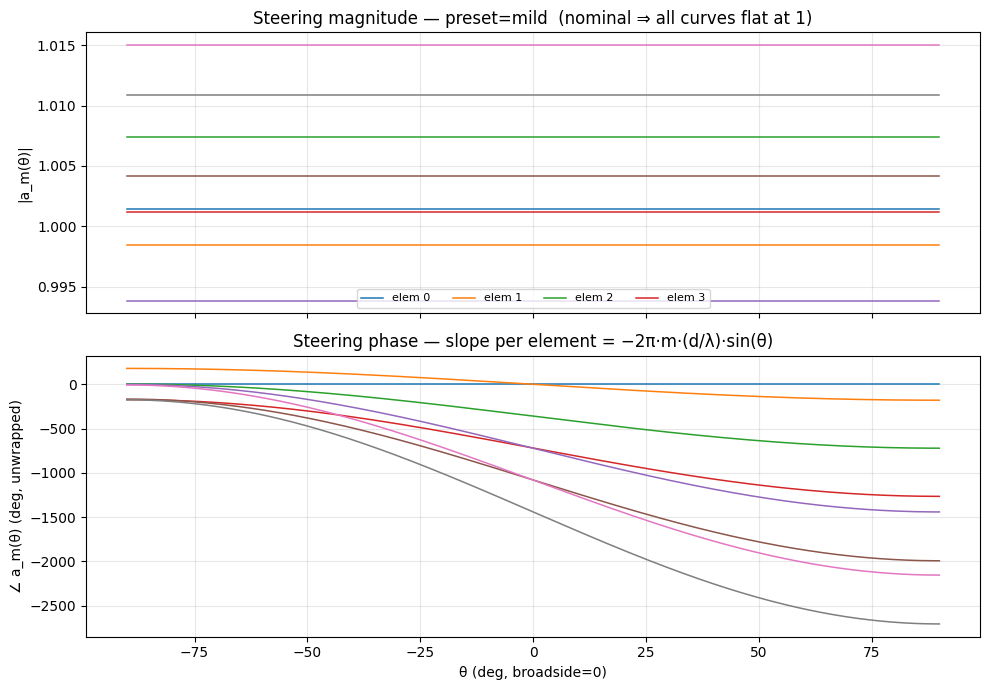

Max |Δ magnitude|          : 0.0150
Max |Δ phase| (deg)        : 12.517


In [3]:
G = 721
scan_deg = np.linspace(-90.0, 90.0, G)
scan_rad = np.deg2rad(scan_deg)

A = _steering_vector(
    scan_rad, M=M, element_spacing_lambda=ELEMENT_SPACING_LAMBDA,
    gain_err=gain_err, phase_err=phase_err_rad, position_err=pos_err_pct,
)   # [M, G]

# Nominal reference for comparison
A0 = _steering_vector(
    scan_rad, M=M, element_spacing_lambda=ELEMENT_SPACING_LAMBDA,
    gain_err=np.ones(M), phase_err=np.zeros(M), position_err=np.zeros(M),
)

fig, (ax_mag, ax_phase) = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

for m in range(M):
    ax_mag.plot(scan_deg, np.abs(A[m]), lw=1.1, label=f"elem {m}" if m < 4 else None)
    ax_phase.plot(scan_deg, np.unwrap(np.angle(A[m])) * 180 / np.pi, lw=1.1)

ax_mag.set_ylabel("|a_m(θ)|")
ax_mag.set_title(f"Steering magnitude — preset={PRESET}  (nominal ⇒ all curves flat at 1)")
ax_mag.grid(alpha=0.3); ax_mag.legend(ncols=4, fontsize=8, loc="lower center")

ax_phase.set_xlabel("θ (deg, broadside=0)")
ax_phase.set_ylabel("∠ a_m(θ) (deg, unwrapped)")
ax_phase.set_title("Steering phase — slope per element = −2π·m·(d/λ)·sin(θ)")
ax_phase.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Nominal-vs-preset deviation (at a glance)
dev_abs  = np.abs(A) - np.abs(A0)
dev_ph   = np.angle(A * A0.conj())
print(f"Max |Δ magnitude|          : {np.abs(dev_abs).max():.4f}")
print(f"Max |Δ phase| (deg)        : {np.rad2deg(np.abs(dev_ph).max()):.3f}")


### 2b. Heatmap view  — magnitude and phase over (element × angle)

Same `A` as above, rendered as a 2-D heatmap.  Easy to spot per-element
anomalies at a glance.


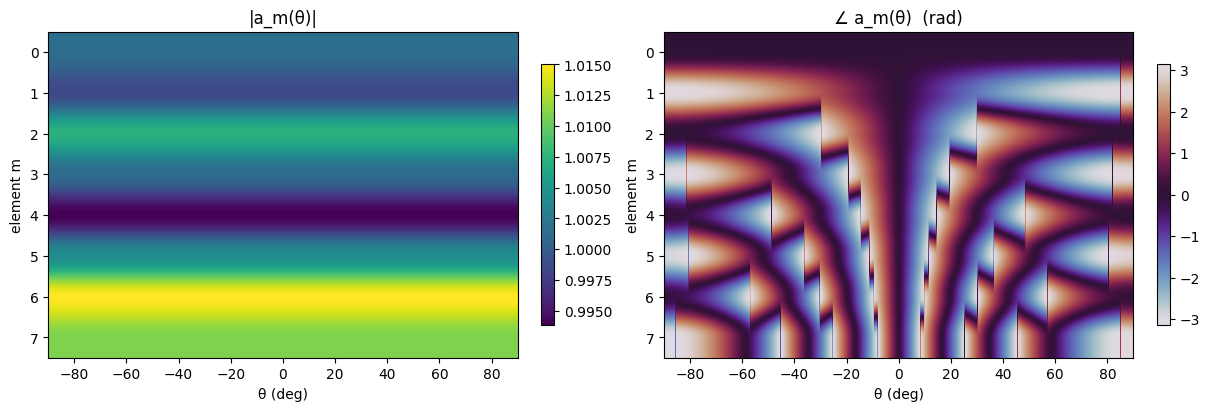

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

im1 = ax1.imshow(np.abs(A), aspect="auto", cmap="viridis",
                 extent=[scan_deg[0], scan_deg[-1], M - 0.5, -0.5])
ax1.set_ylabel("element m"); ax1.set_xlabel("θ (deg)")
ax1.set_title("|a_m(θ)|")
fig.colorbar(im1, ax=ax1, shrink=0.8)

im2 = ax2.imshow(np.angle(A), aspect="auto", cmap="twilight",
                 extent=[scan_deg[0], scan_deg[-1], M - 0.5, -0.5],
                 vmin=-np.pi, vmax=np.pi)
ax2.set_ylabel("element m"); ax2.set_xlabel("θ (deg)")
ax2.set_title("∠ a_m(θ)  (rad)")
fig.colorbar(im2, ax=ax2, shrink=0.8)
plt.show()


## 3. Beam pattern (2-D)

For a look direction `φ` (the "beamformer weight angle"), the beam
pattern is

```
P(θ, φ) = |a(φ)^H a(θ)|² / M²
```

i.e. how strongly the array steered to `φ` responds to a plane wave from
`θ`.  The perfectly-calibrated ULA has a `sinc`-shaped main lobe along
the diagonal `θ = φ`, side-lobes at about −13 dB, and nulls wherever
`(m · (d/λ)) · (sin θ − sin φ)` is an integer.


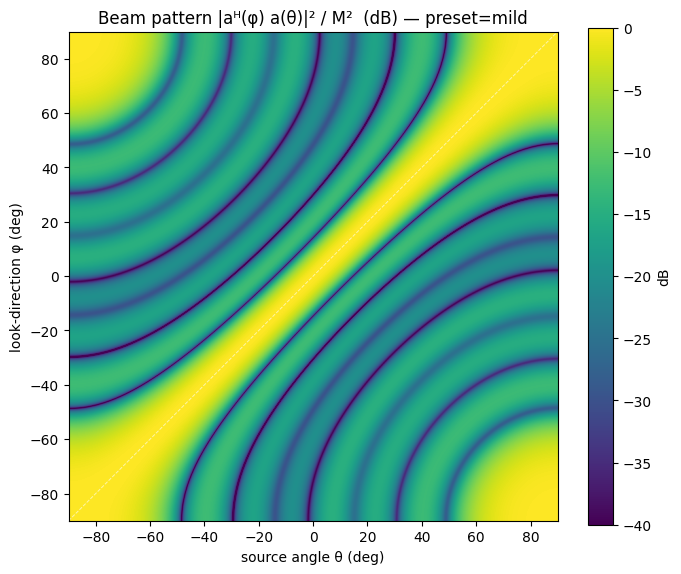

In [5]:
# P[i, j] = response when steered to angles[i] to a source at angles[j]
BP = np.abs(A.conj().T @ A) ** 2 / (M ** 2)     # [G, G]
BP_dB = 10 * np.log10(np.clip(BP, 1e-8, None))

fig, ax = plt.subplots(1, 1, figsize=(7, 5.8))
im = ax.imshow(BP_dB, origin="lower", cmap="viridis", vmin=-40, vmax=0,
               extent=[scan_deg[0], scan_deg[-1], scan_deg[0], scan_deg[-1]])
ax.set_xlabel("source angle θ (deg)")
ax.set_ylabel("look-direction φ (deg)")
ax.set_title(f"Beam pattern |aᴴ(φ) a(θ)|² / M²  (dB) — preset={PRESET}")
fig.colorbar(im, ax=ax, label="dB")
ax.plot([scan_deg[0], scan_deg[-1]], [scan_deg[0], scan_deg[-1]],
        ls="--", lw=0.7, color="white", alpha=0.6)
plt.tight_layout(); plt.show()


### 3b. Vertical cuts + 3 dB beamwidth

Pick a couple of look directions and cut through the beam pattern to
read off the main-lobe 3 dB width and side-lobe level.


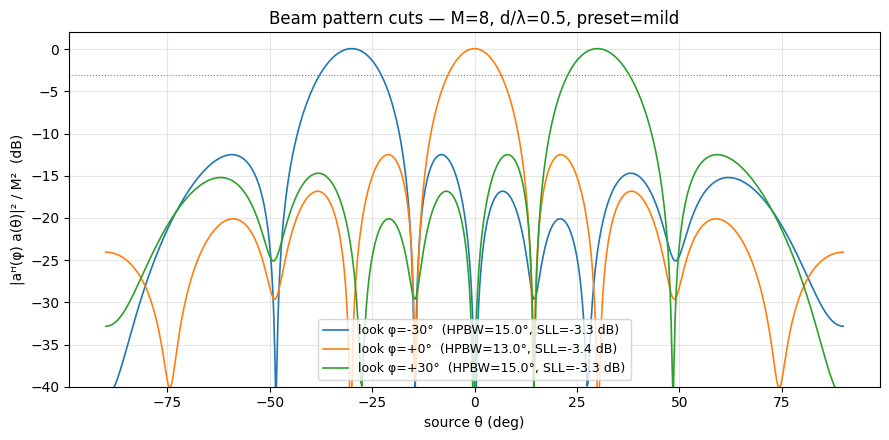

In [6]:
def hpbw_and_sll(cut_dB, angles_deg):
    peak = np.argmax(cut_dB)
    # 3 dB beamwidth
    left = peak
    while left > 0 and cut_dB[left] > cut_dB[peak] - 3.0:
        left -= 1
    right = peak
    while right < len(cut_dB) - 1 and cut_dB[right] > cut_dB[peak] - 3.0:
        right += 1
    hpbw = angles_deg[right] - angles_deg[left]
    # First side-lobe: highest peak outside the main lobe
    outside = cut_dB.copy()
    outside[left:right+1] = -np.inf
    sll = outside.max() - cut_dB[peak]
    return hpbw, sll


TARGET_ANGLES_DEG = [-30.0, 0.0, 30.0]
fig, ax = plt.subplots(1, 1, figsize=(9, 4.5))
for phi_deg in TARGET_ANGLES_DEG:
    j = int(np.argmin(np.abs(scan_deg - phi_deg)))
    cut = BP_dB[j]
    hpbw, sll = hpbw_and_sll(cut, scan_deg)
    ax.plot(scan_deg, cut, lw=1.2,
            label=f"look φ={phi_deg:+.0f}°  (HPBW={hpbw:.1f}°, SLL={sll:+.1f} dB)")
ax.axhline(-3, color="gray", ls=":", lw=0.8)
ax.set_xlabel("source θ (deg)"); ax.set_ylabel("|aᴴ(φ) a(θ)|² / M²  (dB)")
ax.set_ylim(-40, 2)
ax.set_title(f"Beam pattern cuts — M={M}, d/λ={ELEMENT_SPACING_LAMBDA}, preset={PRESET}")
ax.grid(alpha=0.3); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()


## 4. Preset-vs-preset comparison

Overlay the 2-D beam patterns for `none` / `mild` / `harsh` so you can
see the side-lobe lift and pattern degradation caused by calibration
errors.  This is the whole motivation for ReconUNet, SubspaceNet, and
the ViT baselines — model-based DOA is fragile under real-world array
errors.


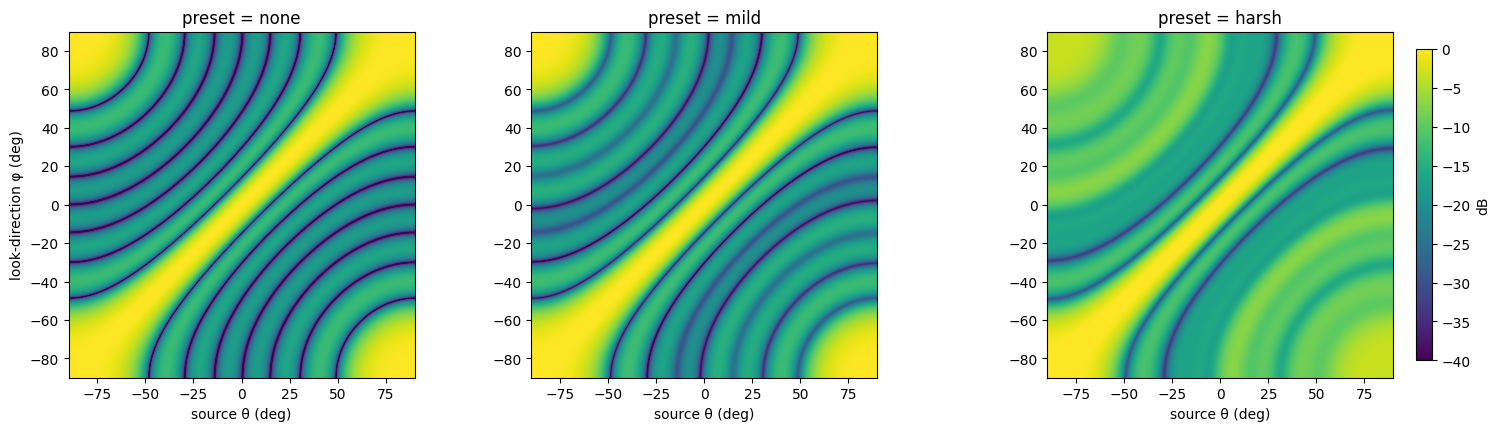

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for ax, name in zip(axes, ("none", "mild", "harsh")):
    rng_ = np.random.default_rng(SEED)
    p = PRESETS[name]
    ge  = 1.0 + (p["gain_err_dB"] / 8.686) * rng_.standard_normal(M)
    phe = np.deg2rad(p["phase_err_deg"]) * rng_.standard_normal(M)
    pe  = (p["position_err_pct"] / 100.0) * rng_.standard_normal(M)
    A_p = _steering_vector(
        scan_rad, M=M, element_spacing_lambda=ELEMENT_SPACING_LAMBDA,
        gain_err=ge, phase_err=phe, position_err=pe,
    )
    BP_p = np.abs(A_p.conj().T @ A_p) ** 2 / (M ** 2)
    BP_p_dB = 10 * np.log10(np.clip(BP_p, 1e-8, None))
    im = ax.imshow(BP_p_dB, origin="lower", cmap="viridis", vmin=-40, vmax=0,
                   extent=[scan_deg[0], scan_deg[-1], scan_deg[0], scan_deg[-1]])
    ax.set_title(f"preset = {name}")
    ax.set_xlabel("source θ (deg)")
    if ax is axes[0]:
        ax.set_ylabel("look-direction φ (deg)")
fig.colorbar(im, ax=axes[-1], shrink=0.9, label="dB")
plt.show()


## 5. Quick pass/fail checks

Programmatic sanity of the forward model: a clean ULA at `θ = 0`
(broadside) must produce an all-ones steering vector, and at `θ = 30°`
(with `d/λ = 0.5`) the `m`-th element phase must be exactly `−j·π·m/2`.


In [8]:
A0   = _steering_vector(np.array([0.0]), M=M,
                        element_spacing_lambda=ELEMENT_SPACING_LAMBDA,
                        gain_err=np.ones(M), phase_err=np.zeros(M),
                        position_err=np.zeros(M))[:, 0]
A30  = _steering_vector(np.array([np.deg2rad(30.0)]), M=M,
                        element_spacing_lambda=ELEMENT_SPACING_LAMBDA,
                        gain_err=np.ones(M), phase_err=np.zeros(M),
                        position_err=np.zeros(M))[:, 0]
expected30 = np.exp(-1j * 2*np.pi * np.arange(M) * ELEMENT_SPACING_LAMBDA * np.sin(np.deg2rad(30.0)))

err_bs = np.max(np.abs(A0 - np.ones(M)))
err_30 = np.max(np.abs(A30 - expected30))
print(f"[broadside]  |A(0°)  - 1|_max                         = {err_bs:.2e}   (expect 0)")
print(f"[θ=30°]     |A(30°) - exp(-j·2π·m·(d/λ)·sin(30°))|_max = {err_30:.2e}   (expect 0)")
assert err_bs < 1e-12 and err_30 < 1e-12, "forward-model bug!"
print("forward model OK")


[broadside]  |A(0°)  - 1|_max                         = 0.00e+00   (expect 0)
[θ=30°]     |A(30°) - exp(-j·2π·m·(d/λ)·sin(30°))|_max = 0.00e+00   (expect 0)
forward model OK
